In [13]:
#import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

#file path
filepath = 'electricity_consumption_data.csv'  # Update this with your CSV file path



#Data Loading and Pre-processing
"""
Load data from CSV file and perform preprocessing
"""
#Load data

data = pd.read_csv(filepath)
print("Data loaded successfully. Shape:", data.shape)


#Display basic info
print("\nData Info:")
print(data.info())

#Handle missing values
print("\nMissing values before handling:")
print(data.isnull().sum())

#Fill missing values with column mean
data = data.fillna(data.mean())

print("\nMissing values after handling:")
print(data.isnull().sum())

#Feature selection getting last column as target and others as features

X = data.iloc[:, :-1]  # All columns except last
y = data.iloc[:, -1]   # Last column as target

#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Feature scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData preprocessing completed.")
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")
    
    

Data loaded successfully. Shape: (30, 6)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Sample                           30 non-null     int64
 1   Temperature (°C)                 30 non-null     int64
 2   Time of the Day                  30 non-null     int64
 3   Population Density (people/Km²)  30 non-null     int64
 4   Industrial Activity Level        30 non-null     int64
 5   Electricity Consumption (MW)     30 non-null     int64
dtypes: int64(6)
memory usage: 1.5 KB
None

Missing values before handling:
Sample                             0
Temperature (°C)                   0
Time of the Day                    0
Population Density (people/Km²)    0
Industrial Activity Level          0
Electricity Consumption (MW)       0
dtype: int64

Missing values after handling:
Sample                

In [14]:
#Model Training

print("\nTraining Random Forest Regressor...")
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10,
    min_samples_split=5
)

model.fit(X_train, y_train)
print("Model training completed.")


Training Random Forest Regressor...
Model training completed.



Evaluating model...

Model Evaluation Metrics:
MAE: 16.7013
MSE: 321.7530
RMSE: 17.9375
R2 Score: 0.8967

Plotting feature importance...


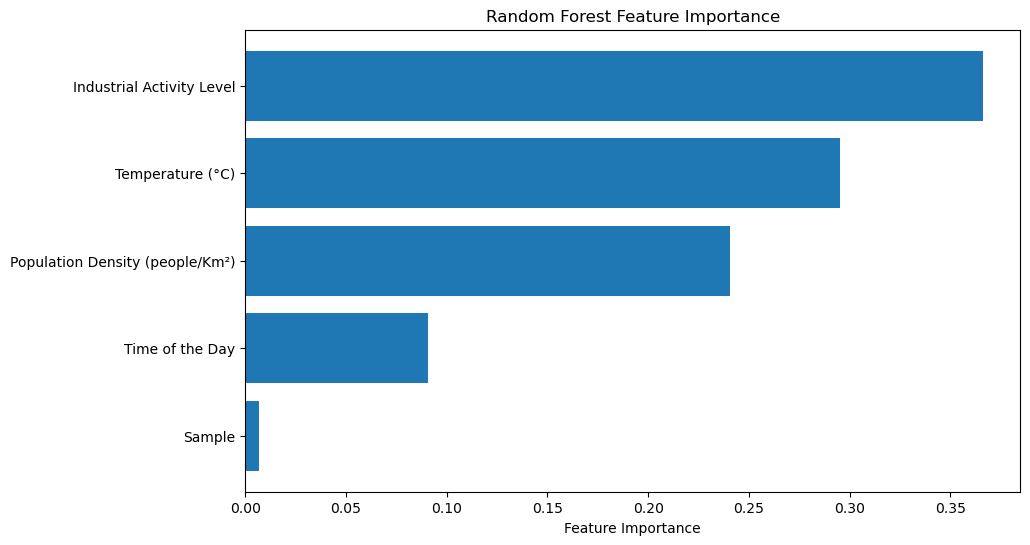

In [15]:
## 3. Evaluation Metrics Computation

print("\nEvaluating model...")
predictions = model.predict(X_test)

#calculate regression metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

#create a dictionary of metrics
metrics = {
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2 Score': r2
}

#print metrics
print("\nModel Evaluation Metrics:")
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot feature importance
if hasattr(model, 'feature_importances_'):
    print("\nPlotting feature importance...")
    feature_importance = model.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    
    # Get feature names from the original data (excluding the target column)
    feature_names = data.columns[:-1]  # All columns except the last one
    
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
    plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx])
    plt.xlabel('Feature Importance')
    plt.title('Random Forest Feature Importance')
    plt.show()

    

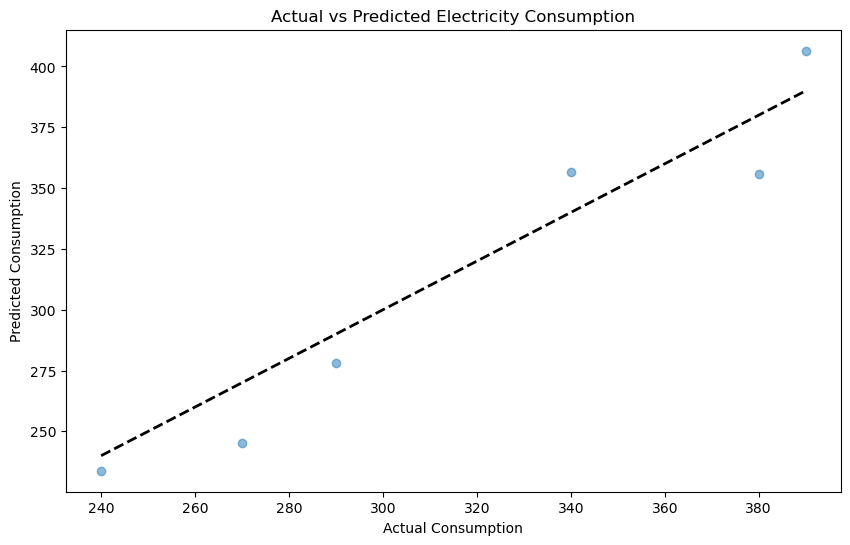

In [16]:
#Model Evaluation and Performance Reporting
#Plot actual vs predicted values

plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Consumption')
plt.ylabel('Predicted Consumption')
plt.title('Actual vs Predicted Electricity Consumption')
plt.show()

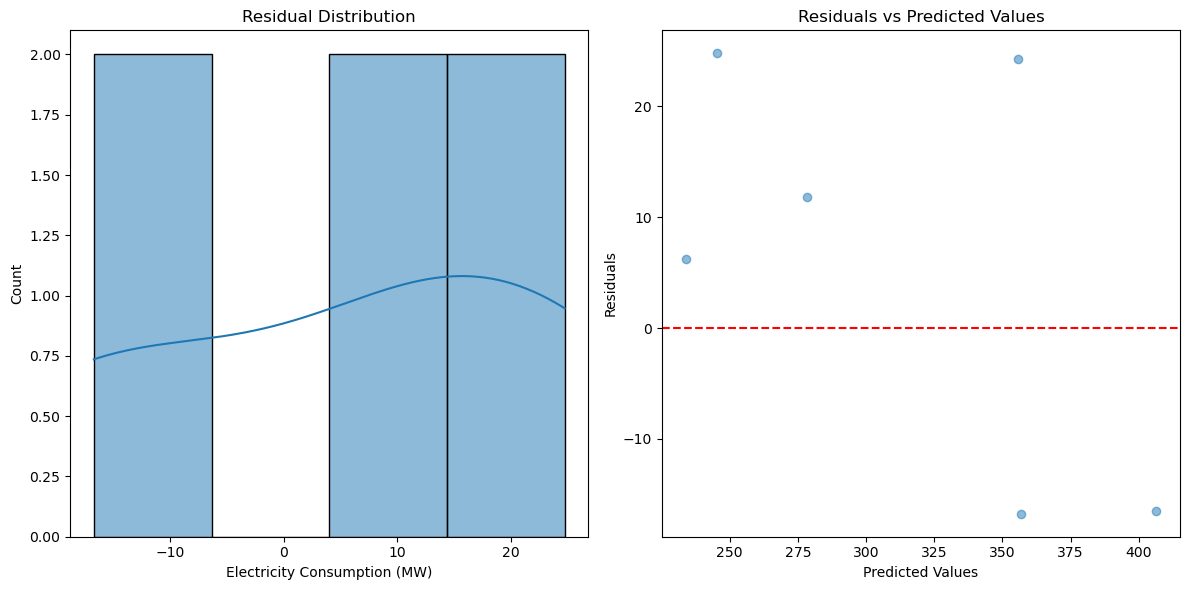

In [17]:
#Analyze and plot residuals

residuals = y_test - predictions

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Residual Distribution')

plt.subplot(1, 2, 2)
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')

plt.tight_layout()
plt.show()